<a href="https://colab.research.google.com/github/kunkashyap/Machine-Learning/blob/main/Feature_Scaling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!pip install pandas

In [6]:
import pandas as pd

In [7]:
df = pd.read_csv('/content/scaling_with_outlier_dataset.csv')
df

,Age,Income,Experience
0,22,30000,1
1,25,35000,2
2,28,40000,3
3,30,45000,4
4,32,50000,5
5,35,55000,6
6,38,60000,7
7,40,500000,8


In [8]:
from sklearn.preprocessing import RobustScaler

In [9]:
rs = RobustScaler()
df['Income'] = rs.fit_transform(df[['Income']])
df

,Age,Income,Experience
0,22,-1.000000,1
1,25,-0.714286,2
2,28,-0.428571,3
3,30,-0.142857,4
4,32,0.142857,5
5,35,0.428571,6
6,38,0.714286,7
7,40,25.857143,8


In [10]:
from sklearn.preprocessing import MinMaxScaler
mm = MinMaxScaler()
df['Age'] = mm.fit_transform(df[['Age']])
df

,Age,Income,Experience
0,0.000000,-1.000000,1
1,0.166667,-0.714286,2
2,0.333333,-0.428571,3
3,0.444444,-0.142857,4
4,0.555556,0.142857,5
5,0.722222,0.428571,6
6,0.888889,0.714286,7
7,1.000000,25.857143,8


we can check whether there is an outlier or not!

<Axes: ylabel='Experience'>

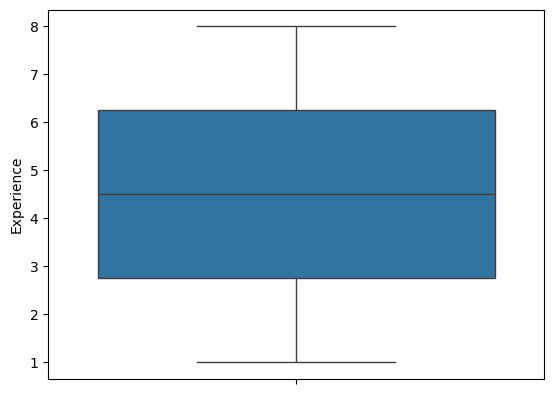

In [11]:
from matplotlib import pyplot as plt
import seaborn as sns
sns.boxplot(df['Experience'])

<Axes: ylabel='Income'>

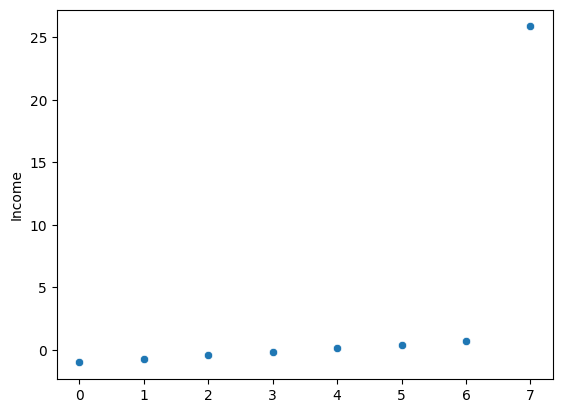

In [12]:
sns.scatterplot(data=df['Income'])

<Axes: xlabel='Income', ylabel='Count'>

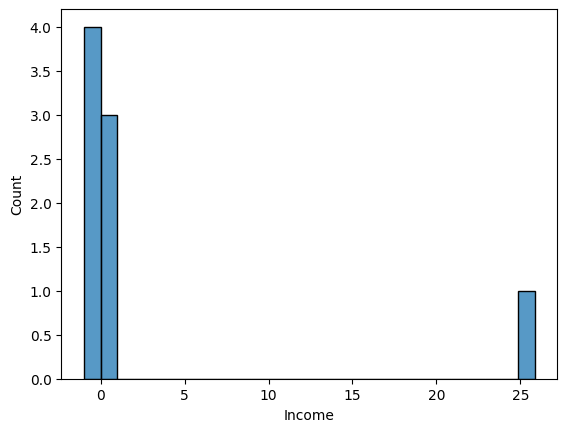

In [13]:
sns.histplot(data=df['Income'])

<Axes: >

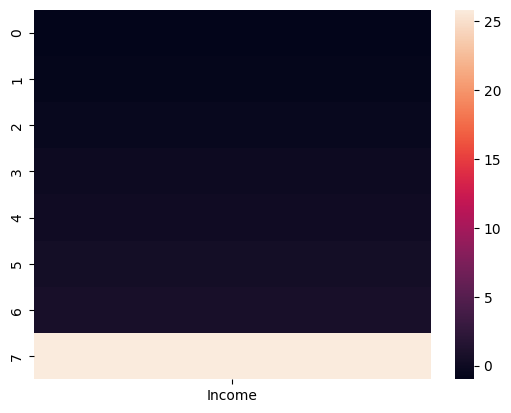

In [14]:
sns.heatmap(data=df[['Income']])

In [15]:
#iqr -> min max anything beyond this line is considered outlier
#min - q1-1.5*IQR
#max - q3+1.5*IQR

#IQR = Q3-Q1


#if df['Income'] > MAX -> OUTLIER!
#if df['Income'] < MIN -> OUTLIER!

In [16]:
q1 = df['Income'].quantile(0.25)
q3 = df['Income'].quantile(0.75)
iqr = q3-q1
print(q1,q3,iqr)

-0.5 0.5 1.0


Detect outliers

In [17]:
import numpy as np

In [18]:
df2 = pd.DataFrame({'salary': [30,35,40,38,36,42,33,400]})
lower = df2['salary'].quantile(0.05)  #fifth percentile
upper = df2['salary'].quantile(0.95) #95th percentile

#Detect
outliers = df2[(df2['salary']<lower) | (df2['salary']>upper)]  #condition for outlier
print(outliers)

   salary
0      30
7     400


Trimming the outlier

In [20]:
Q1, Q3 = df2['salary'].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR

# Remove outlier rows entirely
df2_trimmed = df2[(df2['salary'] >= lower) & (df2['salary'] <= upper)]
print(f"Rows: {len(df2)} → {len(df2_trimmed)}")

Rows: 8 → 7


*Capping* (setting the limits)